In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from scipy.stats import pearsonr
plt.rcParams['font.family']='ARIAL'
plt.rcParams['font.family']='ARIAL'
plt.rcParams['pdf.fonttype'] = 'truetype'
plt.rcParams["mathtext.rm"] = "ARIAL"
plt.rcParams['mathtext.it'] = 'ARIAL'
plt.rcParams['mathtext.bf'] = 'ARIAL'
plt.rcParams['font.sans-serif']=['ARIAL']
plt.rcParams['axes.unicode_minus'] =False
plt.rcParams['axes.linewidth']=0.5 
plt.rcParams['axes.labelsize']=7
plt.rcParams['axes.titlesize']=7
plt.rcParams['xtick.labelsize']=6
plt.rcParams['ytick.labelsize']=6
plt.rcParams['legend.fontsize']=6.5
plt.rcParams['legend.title_fontsize'] = 7
plt.rcParams['xtick.major.size']= 3 
plt.rcParams['xtick.minor.size']= 1.5 
plt.rcParams['xtick.major.width']= 0.5 
plt.rcParams['xtick.minor.width']= 0.4 
plt.rcParams['ytick.major.size']= 3 
plt.rcParams['ytick.minor.size']= 1.5 
plt.rcParams['ytick.major.width']= 0.45 
plt.rcParams['ytick.minor.width']= 0.4 

In [2]:
from adjustText import adjust_text

In [7]:
df_gene=pd.read_csv("/wanglab1/gangx/data2/HLF/gencode.v40.pri.annotation_gene.bed",sep="\t",header=None)
df_gene["GENEID"]=df_gene[3].apply(lambda x:x.split(":")[0])
df_gene["GENESYMBOL"]=df_gene[3].apply(lambda x:x.split(":")[1])
df_gene=df_gene[~df_gene[4].isin({"miRNA","snoRNA","misc_RNA","scaRNA","ribozyme","scRNA","vault_RNA","snRNA","sRNA","rRNA","rRNA_pseudogene","Mt_rRNA","Mt_tRNA",'TEC'})].copy()

In [8]:
df_gene

,0,1,2,3,4,5,GENEID,GENESYMBOL
0,chr1,11868,14409,ENSG00000223972.5:DDX11L1,transcribed_unprocessed_pseudogene,+,ENSG00000223972.5,DDX11L1
1,chr1,14403,29570,ENSG00000227232.5:WASH7P,unprocessed_pseudogene,-,ENSG00000227232.5,WASH7P
3,chr1,29553,31109,ENSG00000243485.5:MIR1302-2HG,lncRNA,+,ENSG00000243485.5,MIR1302-2HG
5,chr1,34553,36081,ENSG00000237613.2:FAM138A,lncRNA,-,ENSG00000237613.2,FAM138A
6,chr1,52472,53312,ENSG00000268020.3:OR4G4P,unprocessed_pseudogene,+,ENSG00000268020.3,OR4G4P
...,...,...,...,...,...,...,...,...
61533,chrM,10469,10766,ENSG00000212907.2:MT-ND4L,protein_coding,+,ENSG00000212907.2,MT-ND4L
61534,chrM,10759,12137,ENSG00000198886.2:MT-ND4,protein_coding,+,ENSG00000198886.2,MT-ND4
61538,chrM,12336,14148,ENSG00000198786.2:MT-ND5,protein_coding,+,ENSG00000198786.2,MT-ND5
61539,chrM,14148,14673,ENSG00000198695.2:MT-ND6,protein_coding,-,ENSG00000198695.2,MT-ND6


### Fig.2

In [16]:
df_2=pd.read_csv("/wanglab1/gangx/data2/HLF/240204/result/TPM_DESeq2_spikein.csv")

In [17]:
df_2=df_2[df_2['gene_id'].isin(df_gene['GENEID'])].copy()

In [18]:
df_2['SLBP_media']=df_2[['E2_2A-1','E2_2A-2']].mean(1)
df_2['SLBP_media']=df_2['SLBP_media']/sum(df_2['SLBP_media'])*1e6

In [19]:
df_2_rbp=pd.read_csv("/wanglab1/gangx/data2/HLF/240204/result/normalized_counts_spikein.csv",index_col=0)

In [9]:
df_2_rbp_cpm=df_2_rbp.loc[list(set(df_2_rbp.index)&set(df_gene['GENEID']))].copy()
for i in df_2_rbp_cpm.columns:
    df_2_rbp_cpm[i]=df_2_rbp_cpm[i]/sum(df_2_rbp_cpm[i])*1e6

In [14]:
df_2_rbp_cpm[df_2_rbp_cpm[['E2_2A_1','E2_2A_2']].mean(1)>50]

,E2_2A_1,E2_2A_2,E2_2B_1,E2_2B_2,E2_2C_1,E2_2C_2,Z1_1A_1,Z1_1A_2,Z1_1B_1,Z1_1B_2,Z1_1C_1,Z1_1C_2
ENSG00000152413.15,52.387563,66.608939,0.000000,0.000000,107.848354,110.924096,21.328783,26.047772,38.053198,0.000000,76.453866,62.795376
ENSG00000126012.13,157.162690,299.740225,0.000000,41.018910,213.310682,218.558071,149.301482,182.334401,0.000000,125.600528,215.345055,234.055493
ENSG00000005810.20,314.325379,416.305868,1680.090923,984.453833,662.837891,654.734179,149.301482,208.382173,152.212793,188.400791,551.317321,539.279079
ENSG00000169750.9,91.678236,116.565643,0.000000,41.018910,12.884538,6.580243,0.000000,0.000000,76.106397,94.200396,13.167055,13.700809
ENSG00000125868.16,65.484454,66.608939,0.000000,123.056729,76.830022,77.552864,42.657566,52.095543,190.265992,188.400791,35.253727,43.385896
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000055163.20,52.387563,133.217878,0.000000,41.018910,61.559459,58.282152,127.972699,78.143315,38.053198,94.200396,43.323857,43.766474
ENSG00000090861.17,117.872017,249.783521,148.243317,369.170187,231.921681,229.368471,213.287832,182.334401,152.212793,94.200396,350.838295,344.042546
ENSG00000138834.15,91.678236,133.217878,0.000000,205.094549,10.498512,11.280417,85.315133,26.047772,76.106397,31.400132,18.688723,16.364856
ENSG00000198727.2,52.387563,49.956704,0.000000,123.056729,0.477205,0.000000,149.301482,625.146519,152.212793,188.400791,4.672181,1.141734


In [22]:
histgene=set(df_gene[((df_gene['GENESYMBOL'].str.startswith("H1"))|(df_gene['GENESYMBOL'].str.startswith("H2"))|(df_gene['GENESYMBOL'].str.startswith("H3"))|(df_gene['GENESYMBOL'].str.startswith("H4"))
         )&(df_gene[4]=="protein_coding")]['GENEID'])

In [23]:
len(histgene)

94

In [24]:
df_slbp_plot=df_2[df_2['gene_symbol']!="SLBP"].copy()
df_slbp_plot['-log10pval']=-df_slbp_plot['2Avs2B_padj'].apply(np.log10)
df_slbp_plot['group']="Other"
df_slbp_plot.loc[(df_slbp_plot['2Avs2B_log2FoldChange']>2)&(df_slbp_plot['2Avs2B_padj']<0.05),"group"]="EPN24-SLBP enriched"
df_slbp_plot.loc[(df_slbp_plot['gene_id'].isin(histgene)),"group"]="Histone RNA"
df_slbp_plot['group']=df_slbp_plot['group'].astype("category")
df_slbp_plot['group']=df_slbp_plot['group'].cat.set_categories(["Histone RNA","EPN24-SLBP enriched","Other"])
df_slbp_plot['group2']="Other"
df_slbp_plot.loc[(df_slbp_plot['gene_id'].isin(histgene)),"group2"]="Histone RNA"
df_slbp_plot['group2']=df_slbp_plot['group2'].astype("category")
df_slbp_plot['group2']=df_slbp_plot['group2'].cat.set_categories(["Histone RNA","Other"])

In [25]:
df_slbp_plot1=df_slbp_plot[(df_slbp_plot['2Avs2B_log2FoldChange']>2)&(df_slbp_plot['2Avs2B_padj']<0.05)&(df_slbp_plot['group']!="Other")].copy()

In [26]:
df_slbp_plot1.sort_values(by="SLBP_media",ascending=False,inplace=True)

In [28]:
df_slbp_plot1[['gene_id', 'gene_symbol','SLBP_media','2Avs2B_log2FoldChange',
       '2Avs2B_pvalue', '2Avs2B_padj']].to_csv("table/1C.csv",index=False)

In [57]:
df_slbp_plot1['rank']=df_slbp_plot1['SLBP_media'].rank(ascending=False)

In [41]:
def label_point(x, y, val, ax):
    a = pd.concat({'x': x, 'y': y, 'val': val}, axis=1)
    return [ax.text(point['x']+.1, point['y']-0.04, str(point['val']),fontsize=7) for i, point in a.iterrows()]

meta NOT subset; don't know how to subset; dropped


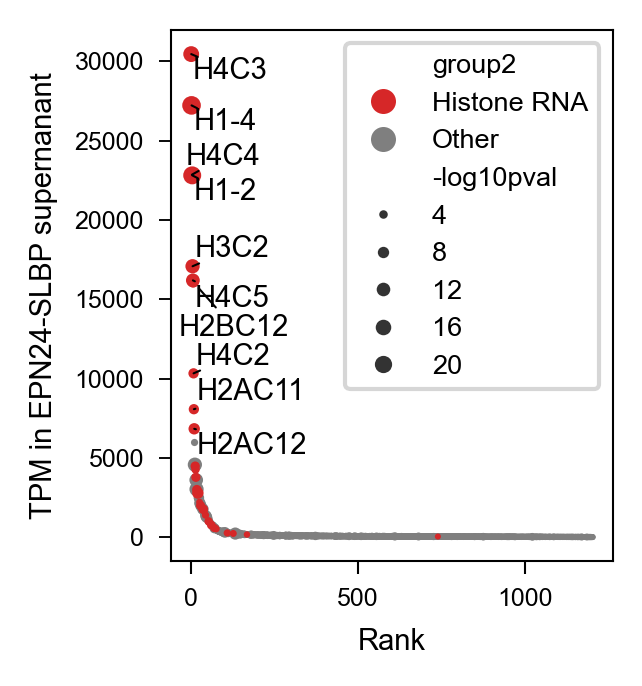

In [80]:
fig = plt.figure(figsize=(1.9, 2.3),dpi=300)
ax = fig.add_subplot(1,1,1)
sns.scatterplot(data=df_slbp_plot1.sort_values(by="group2",ascending=False),x="rank",y="SLBP_media",hue="group2",linewidth=0,size="-log10pval",sizes=(2,20),palette=["tab:red","tab:grey"],ax=ax)
ax.set_xlabel("Rank")
ax.set_ylabel("TPM in EPN24-SLBP supernanant")
df_point=df_slbp_plot1[df_slbp_plot1['gene_symbol'].isin({'H1-4','H1-2','H4C3','H4C4','H3C2','H4C5','H2AC12','H2BC12','H2AC11','H4C2'})]
adjust_text(label_point(df_point['rank'], df_point['SLBP_media'], df_point['gene_symbol'], ax=ax), arrowprops=dict( arrowstyle='-', lw= 0.5, color='black'),ax=ax)
fig.savefig("fig.2-4.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


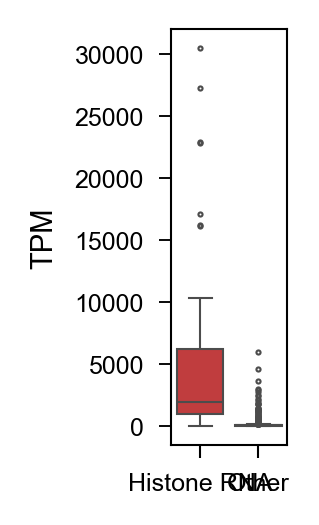

In [79]:
fig = plt.figure(figsize=(0.5, 1.8),dpi=300)
ax = fig.add_subplot(1,1,1)
sns.boxplot(data=df_slbp_plot1,x="group2",y="SLBP_media",flierprops={"marker": "o"},fliersize=0.5,hue="group2",legend=False,palette=["tab:red","tab:grey"],linewidth=0.5,ax=ax)
ax.set_xlabel("")
ax.set_ylabel("TPM")
fig.savefig("fig.2-5.pdf",bbox_inches = 'tight', pad_inches = 0.1)

### Fig.3

In [4]:
df_3_8 =pd.read_csv("/wanglab1/gangx/data2/HLF/240601/result/8HvsEG_DESeq2.csv",index_col=0)
df_3_16=pd.read_csv("/wanglab1/gangx/data2/HLF/240601/result/16HvsEG_DESeq2.csv",index_col=0)
df_3_24=pd.read_csv("/wanglab1/gangx/data2/HLF/240601/result/24HvsEG_DESeq2.csv",index_col=0)
df_3_36=pd.read_csv("/wanglab1/gangx/data2/HLF/240601/result/36HvsEG_DESeq2.csv",index_col=0)
df_3_48=pd.read_csv("/wanglab1/gangx/data2/HLF/240601/result/48HvsEG_DESeq2.csv",index_col=0)
df_3_72=pd.read_csv("/wanglab1/gangx/data2/HLF/240601/result/72HvsEG_DESeq2.csv",index_col=0)

In [5]:
df_3_cpm=pd.read_csv("/wanglab1/gangx/data2/HLF/240601/result/normalized_counts_spikein.csv",index_col=0)

In [6]:
df_3_cpm_rbp=df_3_cpm.loc[list(set(df_3_cpm.index)&set(df_gene['GENEID']))].copy()
for i in df_3_cpm_rbp.columns:
    df_3_cpm_rbp[i]=df_3_cpm_rbp[i]/sum(df_3_cpm_rbp[i])*1e6

In [22]:
df_3_cpm_rbp_auc=pd.merge(df_3_cpm_rbp[["X48H.1","X48H.2"]],df_3_48,left_index=True,right_index=True,how="left")

In [23]:
df_3_cpm_rbp_auc['CPM']=df_3_cpm_rbp_auc[["X48H.1","X48H.2"]].mean(1)

In [131]:
df_3_cpm_rbp_auc

,X48H.1,X48H.2,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,CPM
ENSG00000275923.1,0.000000,0.000000,0.143689,0.000000,5.770300,0.000000,1.000000e+00,NaN,0.000000
ENSG00000159189.13,0.000000,0.000000,1.956744,-1.733799,2.790484,-0.621325,5.343855e-01,7.646345e-01,0.000000
ENSG00000215867.4,0.180906,0.000000,0.213437,-0.010844,5.636044,-0.001924,9.984648e-01,NaN,0.090453
ENSG00000285774.4,0.180906,0.000000,0.855469,0.081056,3.184485,0.025453,9.796933e-01,1.000000e+00,0.090453
ENSG00000167740.10,6.512605,5.890104,34.053689,3.928366,0.841088,4.670576,3.003564e-06,8.952486e-06,6.201354
...,...,...,...,...,...,...,...,...,...
ENSG00000273133.1,0.542717,0.000000,0.723239,3.515500,4.595172,0.765042,4.442464e-01,NaN,0.271359
ENSG00000229980.5,0.723623,0.589010,3.676106,0.520793,1.690886,0.308000,7.580823e-01,9.187839e-01,0.656317
ENSG00000259460.1,1.447246,1.767031,4.194860,5.995204,2.008719,2.984591,2.839582e-03,6.760035e-03,1.607138
ENSG00000184465.16,19.537815,15.314269,66.818031,3.846422,0.516306,7.449882,9.342357e-14,3.850699e-13,17.426042


In [19]:
df_st2=pd.merge(pd.DataFrame(df_3_cpm_rbp[["X48H.1",'X48H.2']].mean(1),columns=["CPM"]),df_3_48.drop(columns=["baseMean","lfcSE","stat"]),left_index=True,right_index=True)

In [20]:
df_st2=pd.merge(df_gene[["GENEID","GENESYMBOL"]],df_st2,left_on="GENEID",right_index=True)

In [8]:
set3_8=set(df_3_8[(df_3_8['padj']<0.05)&(df_3_8['log2FoldChange']>2)].index)&set(df_3_cpm_rbp[df_3_cpm_rbp[['X8H.1','X8H.2']].mean(1)>50].index)
set3_16=set(df_3_16[(df_3_16['padj']<0.05)&(df_3_16['log2FoldChange']>2)].index)&set(df_3_cpm_rbp[df_3_cpm_rbp[['X16H.1','X16H.2']].mean(1)>50].index)
set3_24=set(df_3_24[(df_3_24['padj']<0.05)&(df_3_24['log2FoldChange']>2)].index)&set(df_3_cpm_rbp[df_3_cpm_rbp[['X24H.1','X24H.2']].mean(1)>50].index)
set3_36=set(df_3_36[(df_3_36['padj']<0.05)&(df_3_36['log2FoldChange']>2)].index)&set(df_3_cpm_rbp[df_3_cpm_rbp[['X36H.1','X36H.2']].mean(1)>50].index)
set3_48=set(df_3_48[(df_3_48['padj']<0.05)&(df_3_48['log2FoldChange']>2)].index)&set(df_3_cpm_rbp[df_3_cpm_rbp[['X48H.1','X48H.2']].mean(1)>50].index)
set3_72=set(df_3_72[(df_3_72['padj']<0.05)&(df_3_72['log2FoldChange']>2)].index)&set(df_3_cpm_rbp[df_3_cpm_rbp[['X72H.1','X72H.2']].mean(1)>50].index)

In [24]:
df_3_50 =pd.read_csv("/wanglab1/gangx/data2/HLF/241027/result/IG50vsEG500_DESeq2.csv",index_col=0)
df_3_100=pd.read_csv("/wanglab1/gangx/data2/HLF/241027/result/IG100vsEG500_DESeq2.csv",index_col=0)
df_3_500=pd.read_csv("/wanglab1/gangx/data2/HLF/241027/result/IG500vsEG500_DESeq2.csv",index_col=0)

In [25]:
df_3_cpm1=pd.read_csv("/wanglab1/gangx/data2/HLF/241027/result/normalized_counts.csv",index_col=0)
df_3_cpm1_rbp=df_3_cpm1.loc[list(set(df_3_cpm1.index)&set(df_gene['GENEID']))].copy()
for i in df_3_cpm1_rbp.columns:
    df_3_cpm1_rbp[i]=df_3_cpm1_rbp[i]/sum(df_3_cpm1_rbp[i])*1e6

In [26]:
set3_50 =set(df_3_50[(df_3_50['padj']<0.05)&(df_3_50['log2FoldChange']>2)]['Row.names'])&set(df_3_cpm1_rbp[df_3_cpm1_rbp[['IG50_1','IG50_2']].mean(1)>50].index)
set3_100=set(df_3_100[(df_3_100['padj']<0.05)&(df_3_100['log2FoldChange']>2)]['Row.names'])&set(df_3_cpm1_rbp[df_3_cpm1_rbp[['IG100_1','IG100_2']].mean(1)>50].index)
set3_500=set(df_3_500[(df_3_500['padj']<0.05)&(df_3_500['log2FoldChange']>2)]['Row.names'])&set(df_3_cpm1_rbp[df_3_cpm1_rbp[['IG500_1','IG500_2']].mean(1)>50].index)

In [27]:
len(set3_8),len(set3_16),len(set3_24),len(set3_36),len(set3_48),len(set3_72)

(4283, 4556, 4589, 4681, 4663, 4727)

In [28]:
df_3_num=pd.DataFrame(data={"Hour":["8","16","24","36","48","72"],'Targets':[4283, 4556, 4589, 4681, 4663, 4727]})

meta NOT subset; don't know how to subset; dropped


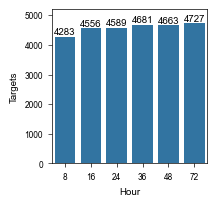

In [748]:
fig = plt.figure(figsize=(2, 2))
ax = fig.add_subplot(1,1,1)
sns.barplot(data=df_3_num,x="Hour",y="Targets",ax=ax)
#sns.scatterplot(data=df_3_num,x="Hour",y="Targets",ax=ax)
ax.set_ylim(0,5200)
ax.bar_label(ax.containers[0], fontsize=7)
#ax.set_xticks([8,16,24,36,48,72])
fig.savefig("fig.3_2.pdf",bbox_inches = 'tight', pad_inches = 0.1)

In [29]:
len(set3_50),len(set3_100),len(set3_500)

(4236, 4404, 4652)

meta NOT subset; don't know how to subset; dropped


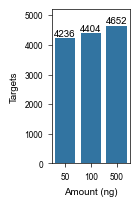

In [751]:
df_3_num=pd.DataFrame(data={"Amount (ng)":["50","100","500"],'Targets':[4236, 4404, 4652]})
fig = plt.figure(figsize=(1, 2))
ax = fig.add_subplot(1,1,1)
sns.barplot(data=df_3_num,x="Amount (ng)",y="Targets",ax=ax)
#sns.scatterplot(data=df_3_num,x="Hour",y="Targets",ax=ax)
ax.set_ylim(0,5200)
ax.bar_label(ax.containers[0], fontsize=7)
#ax.set_xticks([8,16,24,36,48,72])
fig.savefig("fig.3_3.pdf",bbox_inches = 'tight', pad_inches = 0.1)

In [658]:
len(set3_8|set3_16|set3_24|set3_36|set3_48|set3_72)

5596

In [659]:
df_3=pd.concat([df_3_8[["log2FoldChange"]],
                df_3_16[["log2FoldChange"]],
                df_3_24[["log2FoldChange"]],
                df_3_36[["log2FoldChange"]],
                df_3_48[["log2FoldChange"]],
                df_3_72[["log2FoldChange"]]],axis=1)

In [660]:
df_3.columns=["8H","16H","24H","36H","48H","72H"]

In [661]:
df_3_heatmap=df_3.loc[list((set(df_3.index)&set(df_gene['GENEID']))&(set3_8|set3_16|set3_24|set3_36|set3_48|set3_72))]

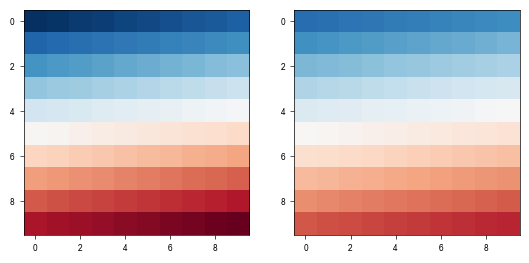

In [4]:
import matplotlib.colors as colors
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

arr = np.linspace(0, 50, 100).reshape((10, 10))
fig, ax = plt.subplots(ncols=2)

cmap = plt.get_cmap('RdBu_r')
new_cmap = truncate_colormap(cmap, 0.12, 0.88)
ax[0].imshow(arr, interpolation='nearest', cmap=cmap)
ax[1].imshow(arr, interpolation='nearest', cmap=new_cmap)
plt.show()

In [10]:
from scipy.stats import fisher_exact
from matplotlib_venn import venn2,venn3

In [11]:
def Exporter_venn2(ax,set_list,label_list,color_list=['r','y','b'],alpha=0.45,bgsize=20000,title=None):
    out = venn2(subsets = set_list,
            set_labels=label_list,
            set_colors=color_list,
            alpha=alpha,
            ax=ax)
    for text in out.set_labels:
        text.set_fontsize(7)
    for text in out.subset_labels:
        if text:
            text.set_fontsize(7)
    fe=fisher_exact([ [len(set_list[1]&set_list[0]), len(set_list[1])],[len(set_list[0]), bgsize]])
    ax.text(0,-1.1,"EnrichmentFold = %.3g\n$\mathit{P}$ = %.3g"%(fe[0],fe[1]),va="center",ha="center",fontsize=7)
    ax.set_title(title)

In [12]:
df_rip=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/refclip/GSE90639_RIP_IGF2BP1_binding_gene.txt",sep="\t")
df_pie=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/refclip/PIE-seq_IGF2BP1.txt",sep='\t',index_col=0)
df_ec1=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/refclip/ENCODE/IGF2BP1_HepG2_rep01.bed",sep="\t",header=None)
df_ec2=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/refclip/ENCODE/IGF2BP1_HepG2_rep02.bed",sep="\t",header=None)
df_ec3=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/refclip/ENCODE/IGF2BP1_K562_rep01.bed",sep="\t",header=None)
df_ec4=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/refclip/ENCODE/IGF2BP1_K562_rep02.bed",sep="\t",header=None)
df_clip1=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/refclip/GSM2071742_IGF2BP1_H9ES_Rep1_eCLIP.clusters.bed",sep='\t',header=None)
df_clip2=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/refclip/GSM2071745_IGF2BP1_H9ES_Rep2_eCLIP.clusters.bed",sep='\t',header=None)

In [13]:
df_clip1['Reads']=df_clip1[3].apply(lambda x:int(x.split("_")[-1]))
df_clip2['Reads']=df_clip2[3].apply(lambda x:int(x.split("_")[-1]))
df_clip1['Geneid']=df_clip1[3].apply(lambda x:x.split(".")[0])
df_clip2['Geneid']=df_clip2[3].apply(lambda x:x.split(".")[0])

In [14]:
df_ec1["GENEID"]=df_ec1[13].apply(lambda x:x.split(":")[0])
df_ec2["GENEID"]=df_ec2[13].apply(lambda x:x.split(":")[0])
df_ec3["GENEID"]=df_ec3[13].apply(lambda x:x.split(":")[0])
df_ec4["GENEID"]=df_ec4[13].apply(lambda x:x.split(":")[0])

In [15]:
df_rip=pd.merge(df_rip,df_gene[["GENESYMBOL","GENEID"]],left_on='geneName',right_on="GENESYMBOL")
df_pie=pd.merge(df_pie,df_gene[["GENESYMBOL","GENEID"]],left_on='GeneSymbol',right_on="GENESYMBOL")

In [16]:
df_postar=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/refclip/POSTAR3_CLIPdb_module_IGF2BP1_binding_sites_sub_info.csv")

In [17]:
df_clip293=pd.read_csv("/wanglab1/gangx/data2/HLF/IGF2BP1/peak/PureCLIP.crosslink_sites_gene.bed",sep="\t",header=None)
df_clip293=df_clip293[(df_clip293[3]>0)&(df_clip293[4]>-10)].copy()
df_clip293['GENEID']=df_clip293[10].apply(lambda x:x.split(":")[0])
len(set(df_clip293['GENEID'])&set(df_gene['GENEID']))

7237

In [18]:
df_clip293

,0,1,2,3,4,5,6,7,8,9,10,11,12,GENEID
2,chr1,629889,629890,2,-7.11001,+,0;2;10;0.0949586;0.000816223;0;17.5104;,chr1,629639,630683,ENSG00000225630.1:MTND2P28,unprocessed_pseudogene,+,ENSG00000225630.1
30,chr1,631649,631650,2,-9.87913,+,0;1;4;0.038262;5.06152e-05;0;4.40732;,chr1,631073,632616,ENSG00000237973.1:MTCO1P12,unprocessed_pseudogene,+,ENSG00000237973.1
31,chr1,631655,631656,2,-9.87176,+,0;1;4;0.0399491;5.15899e-05;0;7.90231;,chr1,631073,632616,ENSG00000237973.1:MTCO1P12,unprocessed_pseudogene,+,ENSG00000237973.1
144,chr1,943336,943337,2,-9.88405,+,0;1;4;0.0365757;4.01467e-05;0;1.30961;,chr1,923922,944575,ENSG00000187634.13:SAMD11,protein_coding,+,ENSG00000187634.13
145,chr1,943341,943342,2,-9.87484,+,0;1;4;0.0369514;4.17014e-05;0;1.45191;,chr1,923922,944575,ENSG00000187634.13:SAMD11,protein_coding,+,ENSG00000187634.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767971,chrM,10955,10956,2,-9.82967,+,0;2;15;0.138302;5.38276e-05;0;20.1197;,chrM,10759,12137,ENSG00000198886.2:MT-ND4,protein_coding,+,ENSG00000198886.2
768086,chrM,11466,11467,2,-7.64034,+,0;2;11;0.104604;0.000480436;0;18.1308;,chrM,10759,12137,ENSG00000198886.2:MT-ND4,protein_coding,+,ENSG00000198886.2
768247,chrM,12335,12336,2,-9.27403,+,0;2;14;0.132257;9.38209e-05;0;19.7787;,chrM,12265,12336,ENSG00000210191.1:MT-TL2,Mt_tRNA,+,ENSG00000210191.1
768268,chrM,12456,12457,2,-9.30538,+,0;3;24;0.218973;9.09258e-05;0;24.2836;,chrM,12336,14148,ENSG00000198786.2:MT-ND5,protein_coding,+,ENSG00000198786.2


In [19]:
PARCLIP_set=set(df_gene[df_gene['GENEID'].apply(lambda x:x.split(".")[0]).isin(set(df_postar[df_postar['Protocol'].str.contains("PARalyzer")]['Target gene ID']))]['GENEID'])
CLIP_set=set(df_clip293['GENEID'])&set(df_gene['GENEID'])

In [24]:
df_3_cpm_rbp_auc['PAR-CLIP']=0
df_3_cpm_rbp_auc.loc[list(PARCLIP_set&set(df_3_cpm_rbp_auc.index)),'PAR-CLIP']=1
df_3_cpm_rbp_auc['CLIP']=0
df_3_cpm_rbp_auc.loc[list(CLIP_set&set(df_3_cpm_rbp_auc.index)),'CLIP']=1

meta NOT subset; don't know how to subset; dropped


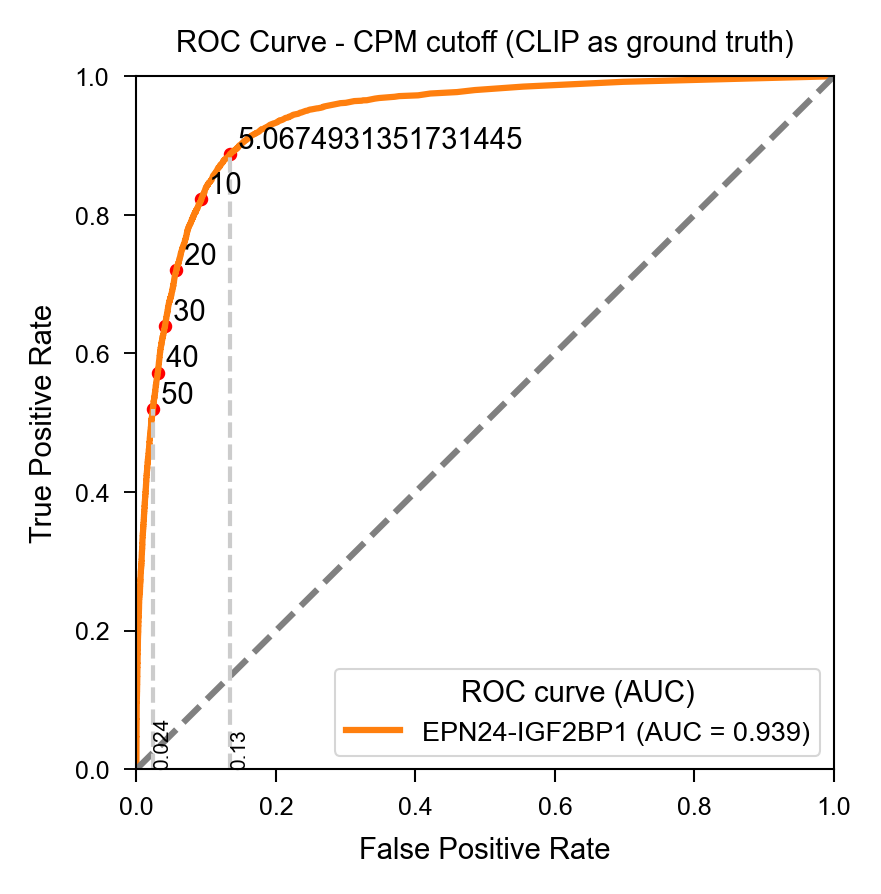

In [196]:
from sklearn.metrics import roc_curve, auc

# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(df_3_cpm_rbp_auc["CLIP"].values, df_3_cpm_rbp_auc['CPM'].values)
roc_auc = auc(fpr, tpr)

best_threshold_idx = np.argmax(tpr - fpr) 
best_threshold = thresholds[best_threshold_idx]

fig=plt.figure(figsize=(3, 3),dpi=300)
ax=fig.add_subplot(1,1,1)
ax.plot(fpr, tpr, color='tab:orange', lw=1.5, label=f'EPN24-IGF2BP1 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')  # 对角线
#ax.plot([0, 1], [1, 0], color='grey', lw=2, linestyle='--')  # 对角线
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - CPM cutoff (CLIP as ground truth)')
ax.legend(loc="lower right",title="ROC curve (AUC)")
ax.legend_.get_frame().set_linewidth(0.5)
# 可选：标记一些阈值点
threshold_points = [best_threshold,10,20,30,40,50]
for threshold in threshold_points:
    idx = np.argmin(np.abs(thresholds - threshold))
    ax.scatter(fpr[idx], tpr[idx], marker='o',s=5, color='red')
    ax.text(fpr[idx], tpr[idx], f' {threshold}', verticalalignment='bottom',fontsize=7)


ax.vlines(fpr[np.argmin(np.abs(thresholds - 50))],ymin=0, ymax=tpr[np.argmin(np.abs(thresholds - 50))], color='0.8', lw=1, linestyle='--')  # 50
ax.text(fpr[np.argmin(np.abs(thresholds - 50))], 0, '%.2g'%(fpr[np.argmin(np.abs(thresholds - 50))]), verticalalignment='bottom',rotation=90,fontsize=5)
ax.vlines(fpr[best_threshold_idx],ymin=0, ymax=tpr[best_threshold_idx], color='0.8', lw=1, linestyle='--')  # 50
ax.text(fpr[best_threshold_idx], 0, '%.2g'%(fpr[best_threshold_idx]), verticalalignment='bottom',rotation=90,fontsize=5)

plt.savefig("ROC/IGF2BP1_CLIP_CPM_ROCcurve.pdf",bbox_inches = 'tight', pad_inches = 0.1)

In [180]:
fpr[np.argmin(np.abs(thresholds - 50))]

0.023788245189780254

meta NOT subset; don't know how to subset; dropped


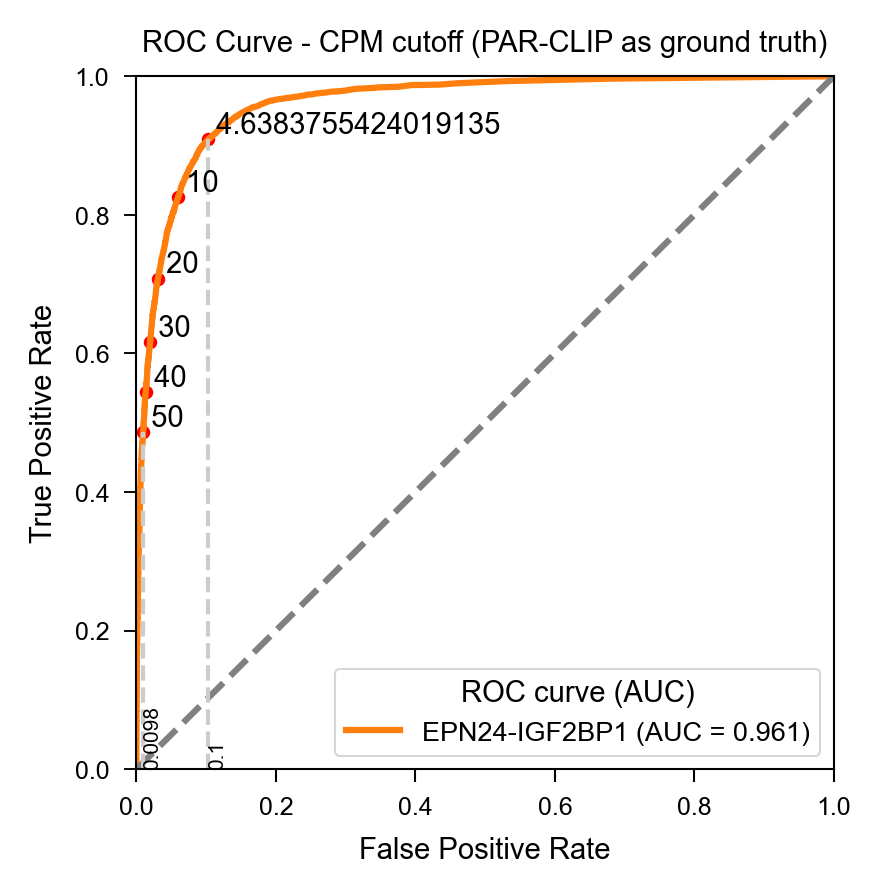

In [195]:

from sklearn.metrics import roc_curve, auc

# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(df_3_cpm_rbp_auc["PAR-CLIP"].values, df_3_cpm_rbp_auc['CPM'].values)
roc_auc = auc(fpr, tpr)

best_threshold_idx = np.argmax(tpr - fpr) 
best_threshold = thresholds[best_threshold_idx]

fig=plt.figure(figsize=(3, 3),dpi=300)
ax=fig.add_subplot(1,1,1)
ax.plot(fpr, tpr, color='tab:orange', lw=1.5, label=f'EPN24-IGF2BP1 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')  # 对角线
#ax.plot([0, 1], [1, 0], color='grey', lw=2, linestyle='--')  # 对角线
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - CPM cutoff (PAR-CLIP as ground truth)')
ax.legend(loc="lower right",title="ROC curve (AUC)")
ax.legend_.get_frame().set_linewidth(0.5)
# 可选：标记一些阈值点
threshold_points = [best_threshold,10,20,30,40,50]
for threshold in threshold_points:
    idx = np.argmin(np.abs(thresholds - threshold))
    ax.scatter(fpr[idx], tpr[idx], marker='o',s=5, color='red')
    ax.text(fpr[idx], tpr[idx], f' {threshold}', verticalalignment='bottom',fontsize=7)

ax.vlines(fpr[np.argmin(np.abs(thresholds - 50))],ymin=0, ymax=tpr[np.argmin(np.abs(thresholds - 50))], color='0.8', lw=1, linestyle='--')  # 50
ax.text(fpr[np.argmin(np.abs(thresholds - 50))], 0, '%.2g'%(fpr[np.argmin(np.abs(thresholds - 50))]), verticalalignment='bottom',rotation=90,fontsize=5)
ax.vlines(fpr[best_threshold_idx],ymin=0, ymax=tpr[best_threshold_idx], color='0.8', lw=1, linestyle='--')  # 50
ax.text(fpr[best_threshold_idx], 0, '%.2g'%(fpr[best_threshold_idx]), verticalalignment='bottom',rotation=90,fontsize=5)

plt.savefig("ROC/IGF2BP1_PAR-CLIP_CPM_ROCcurve.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


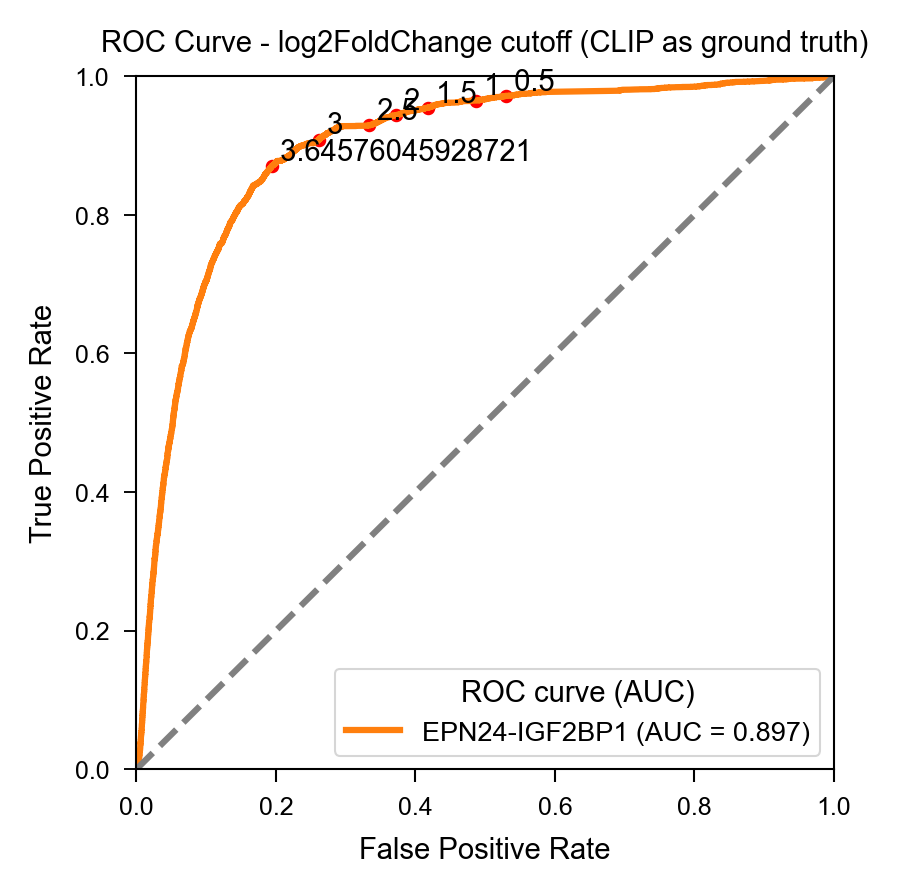

In [28]:
# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(df_3_cpm_rbp_auc["CLIP"].values, df_3_cpm_rbp_auc['log2FoldChange'].values)
roc_auc = auc(fpr, tpr)

best_threshold_idx = np.argmax(tpr - fpr) 
best_threshold = thresholds[best_threshold_idx]

fig=plt.figure(figsize=(3, 3),dpi=300)
ax=fig.add_subplot(1,1,1)
ax.plot(fpr, tpr, color='tab:orange', lw=1.5, label=f'EPN24-IGF2BP1 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')  # 对角线
#ax.plot([0, 1], [1, 0], color='grey', lw=2, linestyle='--')  # 对角线
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - log2FoldChange cutoff (CLIP as ground truth)')
ax.legend(loc="lower right",title="ROC curve (AUC)")
ax.legend_.get_frame().set_linewidth(0.5)


# 可选：标记一些阈值点
threshold_points = [0.5,1,1.5,2,2.5,3,best_threshold]
for threshold in threshold_points:
    idx = np.argmin(np.abs(thresholds - threshold))
    ax.scatter(fpr[idx], tpr[idx], marker='o',s=5, color='red')
    ax.text(fpr[idx], tpr[idx], f' {threshold}', verticalalignment='bottom',fontsize=7)

plt.savefig("ROC/IGF2BP1_CLIP_log2FoldChange_ROCcurve.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


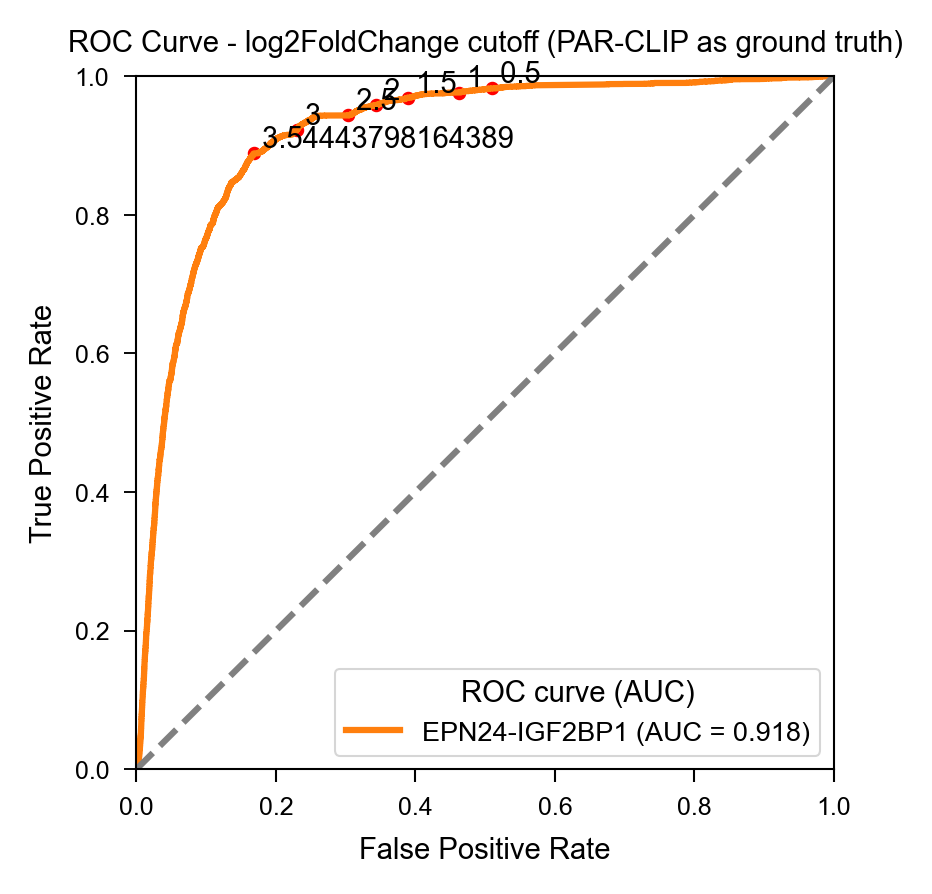

In [29]:
# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(df_3_cpm_rbp_auc["PAR-CLIP"].values, df_3_cpm_rbp_auc['log2FoldChange'].values)
roc_auc = auc(fpr, tpr)

best_threshold_idx = np.argmax(tpr - fpr) 
best_threshold = thresholds[best_threshold_idx]

fig=plt.figure(figsize=(3, 3),dpi=300)
ax=fig.add_subplot(1,1,1)
ax.plot(fpr, tpr, color='tab:orange', lw=1.5, label=f'EPN24-IGF2BP1 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')  # 对角线
#ax.plot([0, 1], [1, 0], color='grey', lw=2, linestyle='--')  # 对角线
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - log2FoldChange cutoff (PAR-CLIP as ground truth)')
ax.legend(loc="lower right",title="ROC curve (AUC)")
ax.legend_.get_frame().set_linewidth(0.5)


# 可选：标记一些阈值点
threshold_points = [0.5,1,1.5,2,2.5,3,best_threshold]
for threshold in threshold_points:
    idx = np.argmin(np.abs(thresholds - threshold))
    ax.scatter(fpr[idx], tpr[idx], marker='o',s=5, color='red')
    ax.text(fpr[idx], tpr[idx], f' {threshold}', verticalalignment='bottom',fontsize=7)

plt.savefig("ROC/IGF2BP1_PAR-CLIP_log2FoldChange_ROCcurve.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


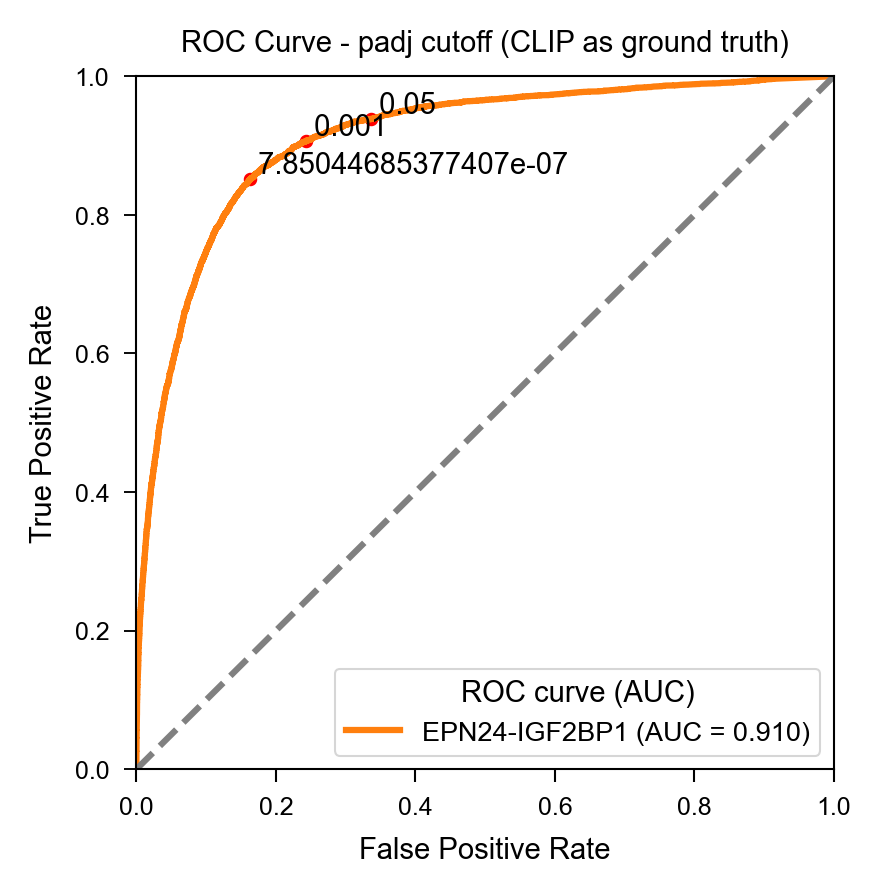

In [30]:
# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(df_3_cpm_rbp_auc.dropna(subset="padj")["CLIP"].values, -df_3_cpm_rbp_auc.dropna(subset="padj")['padj'].values)
roc_auc = auc(fpr, tpr)

best_threshold_idx = np.argmax(tpr - fpr) 
best_threshold = thresholds[best_threshold_idx]

fig=plt.figure(figsize=(3, 3),dpi=300)
ax=fig.add_subplot(1,1,1)
ax.plot(fpr, tpr, color='tab:orange', lw=1.5, label=f'EPN24-IGF2BP1 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')  # 对角线
#ax.plot([0, 1], [1, 0], color='grey', lw=2, linestyle='--')  # 对角线
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - padj cutoff (CLIP as ground truth)')
ax.legend(loc="lower right",title="ROC curve (AUC)")
ax.legend_.get_frame().set_linewidth(0.5)


# 可选：标记一些阈值点
threshold_points = [-0.05,-1e-3,best_threshold]
for threshold in threshold_points:
    idx = np.argmin(np.abs(thresholds - threshold))
    ax.scatter(fpr[idx], tpr[idx], marker='o',s=5, color='red')
    ax.text(fpr[idx], tpr[idx], f' {-threshold}', verticalalignment='bottom',fontsize=7)

plt.savefig("ROC/IGF2BP1_CLIP_padj_ROCcurve.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


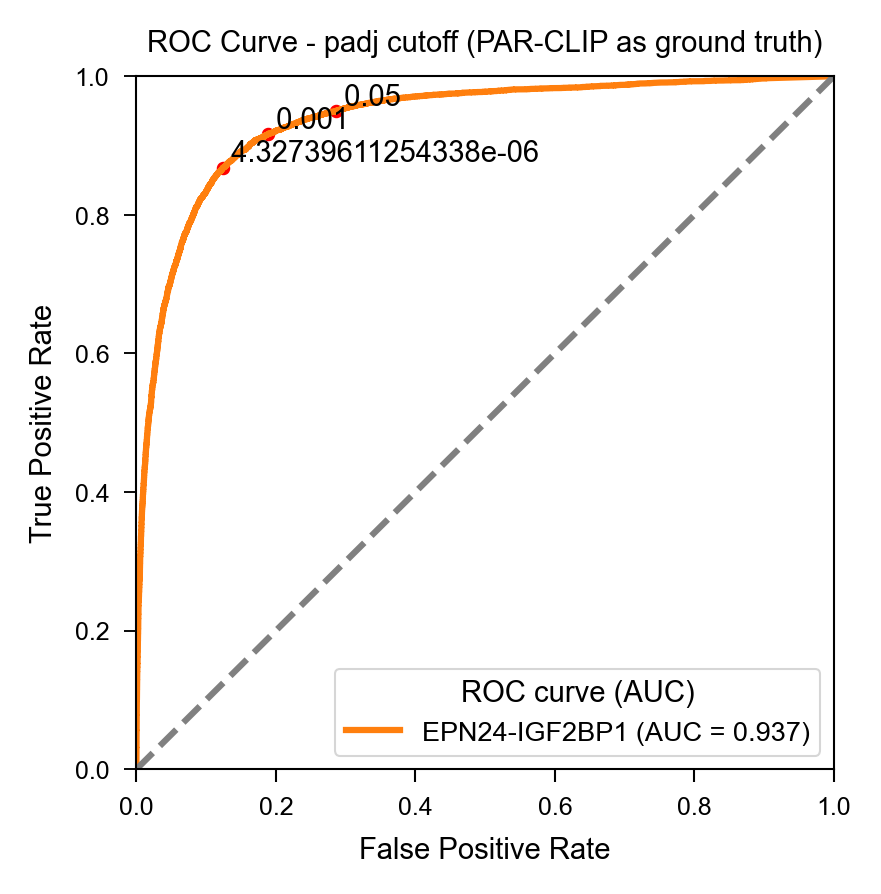

In [31]:
# 计算ROC曲线
fpr, tpr, thresholds = roc_curve(df_3_cpm_rbp_auc.dropna(subset="padj")["PAR-CLIP"].values, -df_3_cpm_rbp_auc.dropna(subset="padj")['padj'].values)
roc_auc = auc(fpr, tpr)

best_threshold_idx = np.argmax(tpr - fpr) 
best_threshold = thresholds[best_threshold_idx]

fig=plt.figure(figsize=(3, 3),dpi=300)
ax=fig.add_subplot(1,1,1)
ax.plot(fpr, tpr, color='tab:orange', lw=1.5, label=f'EPN24-IGF2BP1 (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--')  # 对角线
#ax.plot([0, 1], [1, 0], color='grey', lw=2, linestyle='--')  # 对角线
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - padj cutoff (PAR-CLIP as ground truth)')
ax.legend(loc="lower right",title="ROC curve (AUC)")
ax.legend_.get_frame().set_linewidth(0.5)


# 可选：标记一些阈值点
threshold_points = [-0.05,-1e-3,best_threshold]
for threshold in threshold_points:
    idx = np.argmin(np.abs(thresholds - threshold))
    ax.scatter(fpr[idx], tpr[idx], marker='o',s=5, color='red')
    ax.text(fpr[idx], tpr[idx], f' {-threshold}', verticalalignment='bottom',fontsize=7)

plt.savefig("ROC/IGF2BP1_PAR-CLIP_padj_ROCcurve.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


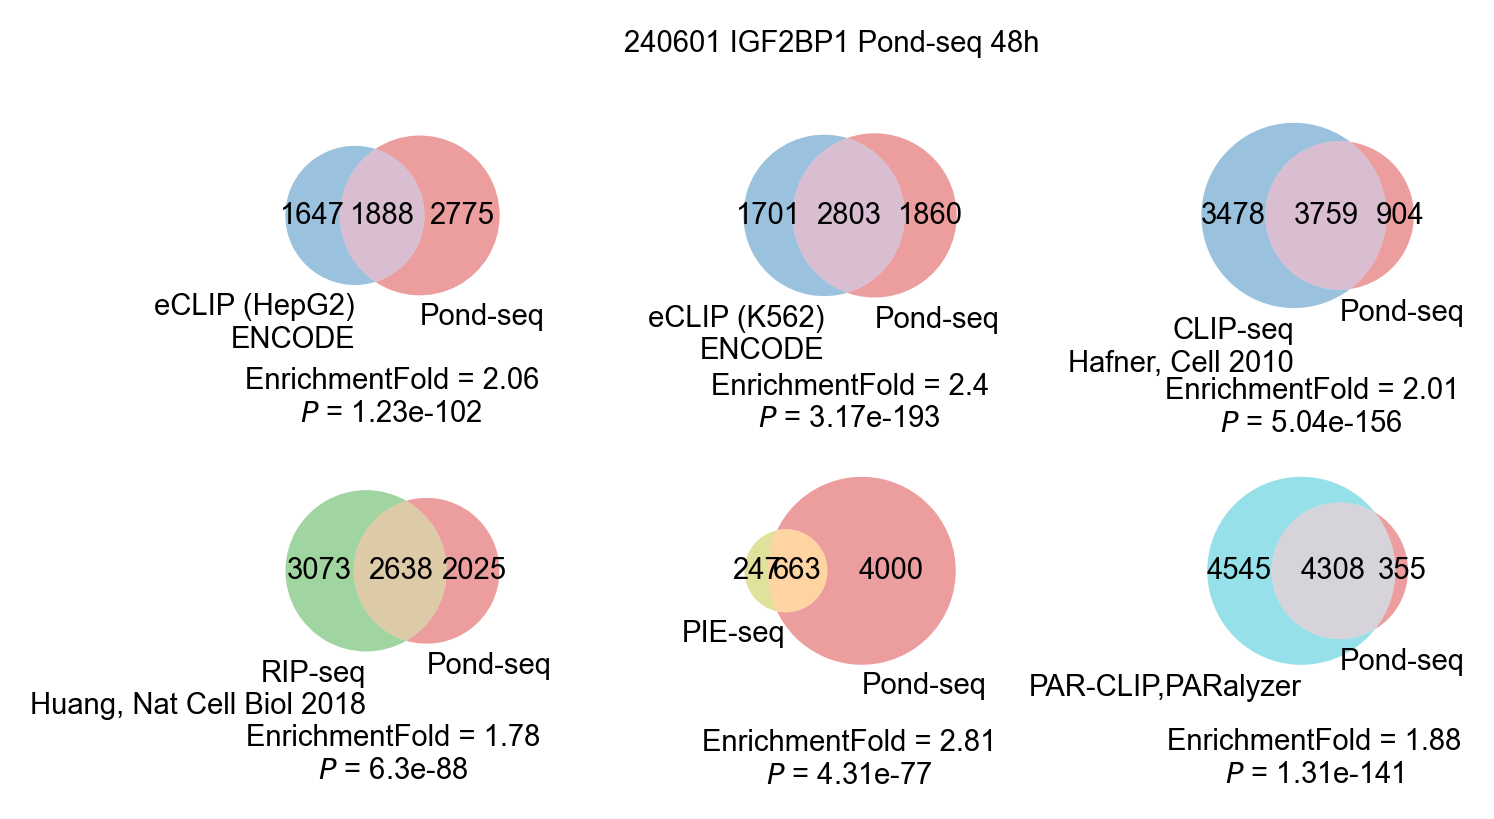

In [120]:
fig,axs=plt.subplots(2,3, figsize=(5,2.5),dpi=300)
plt.suptitle('240601 IGF2BP1 Pond-seq 48h',fontsize=7)
Exporter_venn2(ax=axs[0,0],set_list=[set(df_ec1[df_ec1[7]>=1.301]["GENEID"])&set(df_ec2[df_ec2[7]>=1.301]["GENEID"])&set(df_gene['GENEID']),
                       set3_48],
            label_list=['eCLIP (HepG2)\nENCODE','Pond-seq'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[0,1],set_list=[set(df_ec3[df_ec3[7]>=1.301]["GENEID"])&set(df_ec4[df_ec4[7]>=1.301]["GENEID"])&set(df_gene['GENEID']),
                       set3_48],
            label_list=['eCLIP (K562)\nENCODE','Pond-seq'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[0,2],set_list=[set(df_clip293['GENEID'])&set(df_gene['GENEID']),
                        set3_48],
            label_list=['CLIP-seq\nHafner, Cell 2010','Pond-seq'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,0],set_list=[set(df_rip['GENEID'])&set(df_gene['GENEID']),
                       set3_48],
            label_list=['RIP-seq\nHuang, Nat Cell Biol 2018','Pond-seq'],color_list=['tab:green','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,1],set_list=[set(df_pie['GENEID'])&set(df_gene['GENEID']),
                       set3_48],
            label_list=['PIE-seq','Pond-seq'],color_list=['tab:olive','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,2],set_list=[set(df_postar[df_postar['Protocol'].str.contains("PARalyzer")]['Target gene ID'])&{i.split(".")[0] for i in set(df_gene['GENEID'])},
                       {i.split(".")[0] for i in set3_48}],
            label_list=['PAR-CLIP,PARalyzer','Pond-seq'],color_list=['tab:cyan','tab:red'],bgsize=18000)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.85, hspace=0.6)
plt.savefig("fig.4.pdf",bbox_inches = 'tight', pad_inches = 0.1)

### Fig.5

In [92]:
df_5_rnase=pd.read_csv("/wanglab1/gangx/data2/HLF/240426/result/EIvsEG_DESeq2.csv",index_col=0)

In [96]:
df_5_rnasewo=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/result2/EFvsEG_DESeq2.csv",index_col=0)

In [97]:
df_5_compare=pd.merge(df_5_rnase,df_3_48,left_index=True,right_index=True)

In [98]:
df_5_compare1=pd.merge(df_5_rnase,df_5_rnasewo,left_index=True,right_index=True)

In [7]:
df_5_rbp=pd.read_csv("/wanglab1/gangx/data2/HLF/240426/result/normalized_counts_spikein.csv")

In [8]:
df_5_rbp=df_5_rbp[df_5_rbp['Unnamed: 0'].isin(df_gene['GENEID'])].copy()

In [9]:
for i in df_5_rbp.columns[1:]:
    df_5_rbp[i]=df_5_rbp[i]/sum(df_5_rbp[i])*1e6

In [82]:
df_5_rbpwo=pd.read_csv("/wanglab1/gangx/data2/HLF/240226/result2/normalized_counts_spikein.csv")

In [83]:
df_5_rbpwo=df_5_rbpwo[df_5_rbpwo['Unnamed: 0'].isin(df_gene['GENEID'])].copy()
for i in df_5_rbpwo.columns[1:]:
    df_5_rbpwo[i]=df_5_rbpwo[i]/sum(df_5_rbpwo[i])*1e6

In [84]:
df_5_rbpwo["IGF2BP1-"]=df_5_rbpwo[["E2_EF1","E2_EF2"]].mean(1).apply(np.log1p)
df_5_rbp["IGF2BP1+"]=df_5_rbp[["EI1.R","EI2.R"]].mean(1).apply(np.log1p)

In [85]:
df_5_com = pd.merge(df_5_rbpwo[["Unnamed: 0","IGF2BP1-"]],df_5_rbp[["Unnamed: 0","IGF2BP1+"]],left_on="Unnamed: 0",right_on="Unnamed: 0")

In [86]:
df_5_com=df_5_com[df_5_com.iloc[:,1:].min(1)>0].copy()

meta NOT subset; don't know how to subset; dropped


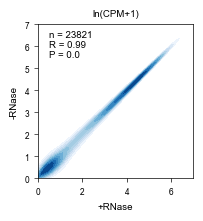

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(2,2))
sns.kdeplot(data=df_5_com,
        x='IGF2BP1+', y='IGF2BP1-',
        cmap="Blues", fill=True,
        clip=(0, 10), cut=10,
        thresh=0.1, levels=12,
        ax=ax,
    )
ax.set_xlim(0,7)
ax.set_ylim(0,7)
ax.set_xlabel("+RNase")
ax.set_ylabel("-RNase")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_title("ln(CPM+1)")
pr=pearsonr(df_5_com['IGF2BP1+'],df_5_com['IGF2BP1-'])
ax.text(x=0.5,y=5.5,s="n = %d\nR = %.2f\nP = %.1f"%(df_5_com.shape[0],pr[0],pr[1]),fontsize=7)
plt.savefig("fig.5_cpm.pdf",bbox_inches = 'tight', pad_inches = 0.1)

In [99]:
set5_rnase=set(df_5_rnase[(df_5_rnase['padj']<0.05)&(df_5_rnase['log2FoldChange']>2)].index)&set(df_5_rbp[df_5_rbp[['EI1.R','EI2.R']].mean(1)>50]['Unnamed: 0'])
set5_rnasewo=set(df_5_rnasewo[(df_5_rnasewo['padj']<0.05)&(df_5_rnasewo['log2FoldChange']>2)].index)&set(df_5_rbpwo[df_5_rbpwo[['E2_EF1','E2_EF2']].mean(1)>50]['Unnamed: 0'])

In [101]:
df_5_compare_plot=df_5_compare.loc[list(set5_rnase|set3_48)]

In [100]:
df_5_compare_plot1=df_5_compare1.loc[list(set5_rnase|set5_rnasewo)]

meta NOT subset; don't know how to subset; dropped


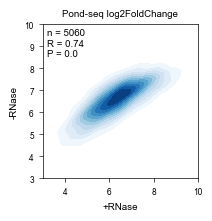

In [183]:
fig, ax = plt.subplots(1, 1, figsize=(2,2))
sns.kdeplot(data=df_5_compare_plot,
        x='log2FoldChange_x', y='log2FoldChange_y',
        cmap="Blues", fill=True,
        clip=(2, 12), cut=10,
        thresh=0.1, levels=12,
        ax=ax,
    )
ax.set_xlim(3,10)
ax.set_ylim(3,10)
ax.set_xlabel("+RNase")
ax.set_ylabel("-RNase")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_title("Pond-seq log2FoldChange")
pr=pearsonr(df_5_compare_plot['log2FoldChange_x'],df_5_compare_plot['log2FoldChange_y'])
ax.text(x=3.2,y=8.55,s="n = %d\nR = %.2f\nP = %.1f"%(df_5_compare_plot.shape[0],pr[0],pr[1]),fontsize=7)
plt.savefig("fig.5_1.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


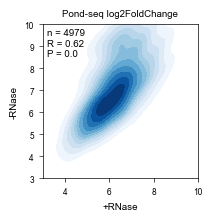

In [182]:
fig, ax = plt.subplots(1, 1, figsize=(2,2))
sns.kdeplot(data=df_5_compare_plot1,
        x='log2FoldChange_x', y='log2FoldChange_y',
        cmap="Blues", fill=True,
        clip=(2, 12), cut=10,
        thresh=0.1, levels=12,
        ax=ax,
    )
ax.set_xlim(3,10)
ax.set_ylim(3,10)
ax.set_xlabel("+RNase")
ax.set_ylabel("-RNase")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_title("Pond-seq log2FoldChange")
pr=pearsonr(df_5_compare_plot1['log2FoldChange_x'],df_5_compare_plot1['log2FoldChange_y'])
ax.text(x=3.2,y=8.55,s="n = %d\nR = %.2f\nP = %.1f"%(df_5_compare_plot1.shape[0],pr[0],pr[1]),fontsize=7)
plt.savefig("fig.5_1-0226.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


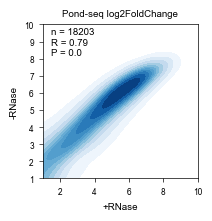

In [145]:
fig, ax = plt.subplots(1, 1, figsize=(2,2))
sns.kdeplot(data=df_5_compare.loc[list(set(df_gene['GENEID'])&set(df_5_compare.index))],
        x='log2FoldChange_x', y='log2FoldChange_y',
        cmap="Blues", fill=True,
        clip=(1, 12), cut=10,
        thresh=0.1, levels=12,
        ax=ax,
    )
ax.set_xlim(1,10)
ax.set_ylim(1,10)
ax.set_xlabel("+RNase")
ax.set_ylabel("-RNase")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_title("Pond-seq log2FoldChange")
pr=pearsonr(df_5_compare.loc[list(set(df_gene['GENEID'])&set(df_5_compare[df_5_compare[['log2FoldChange_x','log2FoldChange_y']].min(1)>1].index))]['log2FoldChange_x'],df_5_compare.loc[list(set(df_gene['GENEID'])&set(df_5_compare[df_5_compare[['log2FoldChange_x','log2FoldChange_y']].min(1)>1].index))]['log2FoldChange_y'])
ax.text(x=1.5,y=8.2,s="n = %d\nR = %.2f\nP = %.1f"%(df_5_compare.loc[list(set(df_gene['GENEID'])&set(df_5_compare[df_5_compare[['log2FoldChange_x','log2FoldChange_y']].min(1)>1].index))].shape[0],pr[0],pr[1]),fontsize=7)
plt.savefig("fig.5_1all.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


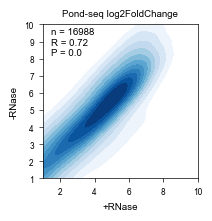

In [184]:
fig, ax = plt.subplots(1, 1, figsize=(2,2))
sns.kdeplot(data=df_5_compare1.loc[list(set(df_gene['GENEID'])&set(df_5_compare1.index))],
        x='log2FoldChange_x', y='log2FoldChange_y',
        cmap="Blues", fill=True,
        clip=(1, 12), cut=10,
        thresh=0.1, levels=12,
        ax=ax,
    )
ax.set_xlim(1,10)
ax.set_ylim(1,10)
ax.set_xlabel("+RNase")
ax.set_ylabel("-RNase")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_title("Pond-seq log2FoldChange")
pr=pearsonr(df_5_compare1.loc[list(set(df_gene['GENEID'])&set(df_5_compare1[df_5_compare1[['log2FoldChange_x','log2FoldChange_y']].min(1)>1].index))]['log2FoldChange_x'],df_5_compare1.loc[list(set(df_gene['GENEID'])&set(df_5_compare1[df_5_compare1[['log2FoldChange_x','log2FoldChange_y']].min(1)>1].index))]['log2FoldChange_y'])
ax.text(x=1.5,y=8.2,s="n = %d\nR = %.2f\nP = %.1f"%(df_5_compare1.loc[list(set(df_gene['GENEID'])&set(df_5_compare1[df_5_compare1[['log2FoldChange_x','log2FoldChange_y']].min(1)>1].index))].shape[0],pr[0],pr[1]),fontsize=7)
plt.savefig("fig.5_1-0226all.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


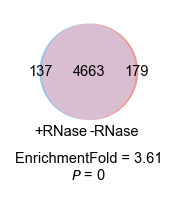

In [ ]:
fig,axs=plt.subplots(1,1, figsize=(1,1),dpi=150)
Exporter_venn2(ax=axs,set_list=[set5_rnase,set5_rnasewo],
            label_list=['+RNase','-RNase'],color_list=['tab:blue','tab:red'],bgsize=18000)
plt.savefig("fig.5_2.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


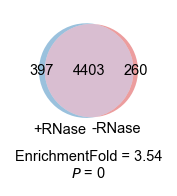

In [187]:
fig,axs=plt.subplots(1,1, figsize=(1,1),dpi=150)
Exporter_venn2(ax=axs,set_list=[set5_rnase,set3_48],
            label_list=['+RNase','-RNase'],color_list=['tab:blue','tab:red'],bgsize=18000)
plt.savefig("fig.5_2.pdf",bbox_inches = 'tight', pad_inches = 0.1)

meta NOT subset; don't know how to subset; dropped


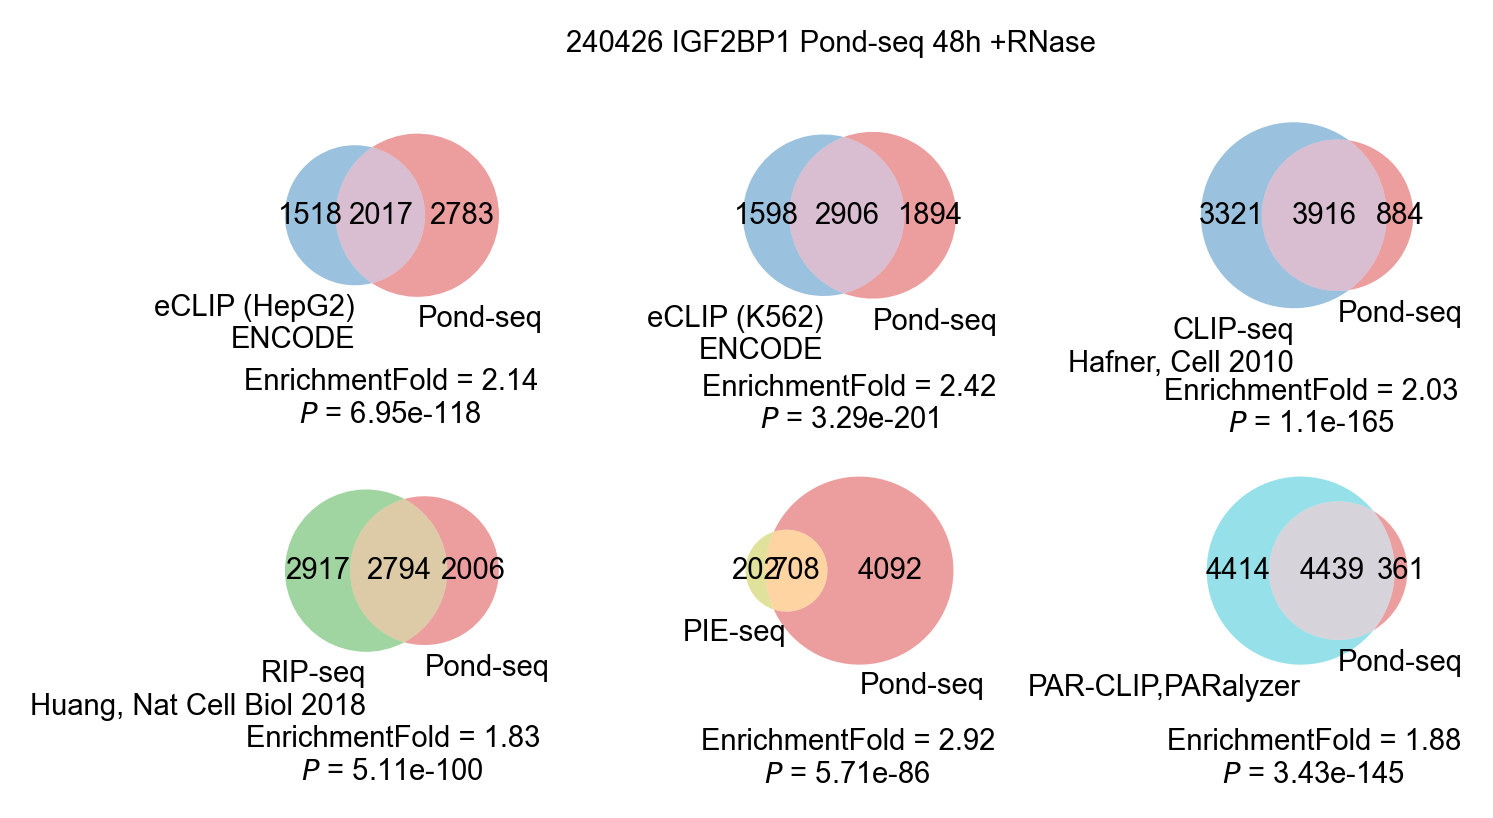

In [189]:
fig,axs=plt.subplots(2,3, figsize=(5,2.5),dpi=300)
plt.suptitle('240426 IGF2BP1 Pond-seq 48h +RNase',fontsize=7)
Exporter_venn2(ax=axs[0,0],set_list=[set(df_ec1[df_ec1[7]>=1.301]["GENEID"])&set(df_ec2[df_ec2[7]>=1.301]["GENEID"])&set(df_gene['GENEID']),
                       set5_rnase],
            label_list=['eCLIP (HepG2)\nENCODE','Pond-seq'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[0,1],set_list=[set(df_ec3[df_ec3[7]>=1.301]["GENEID"])&set(df_ec4[df_ec4[7]>=1.301]["GENEID"])&set(df_gene['GENEID']),
                       set5_rnase],
            label_list=['eCLIP (K562)\nENCODE','Pond-seq'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[0,2],set_list=[set(df_clip293['GENEID'])&set(df_gene['GENEID']),
                        set5_rnase],
            label_list=['CLIP-seq\nHafner, Cell 2010','Pond-seq'],color_list=['tab:blue','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,0],set_list=[set(df_rip['GENEID'])&set(df_gene['GENEID']),
                       set5_rnase],
            label_list=['RIP-seq\nHuang, Nat Cell Biol 2018','Pond-seq'],color_list=['tab:green','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,1],set_list=[set(df_pie['GENEID'])&set(df_gene['GENEID']),
                       set5_rnase],
            label_list=['PIE-seq','Pond-seq'],color_list=['tab:olive','tab:red'],bgsize=18000)
Exporter_venn2(ax=axs[1,2],set_list=[set(df_postar[df_postar['Protocol'].str.contains("PARalyzer")]['Target gene ID'])&{i.split(".")[0] for i in set(df_gene['GENEID'])},
                       {i.split(".")[0] for i in set5_rnase}],
            label_list=['PAR-CLIP,PARalyzer','Pond-seq'],color_list=['tab:cyan','tab:red'],bgsize=18000)
fig.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.85, hspace=0.6)
plt.savefig("fig.5_3.pdf",bbox_inches = 'tight', pad_inches = 0.1)

In [49]:
sampleList=["240601/EG-1","240601/EG-2","240426/EG1-R","240426/EG2-R","240430/EG1-RR","240430/EG2-RR","240911/EG1","240911/EG2","240911/EN1","240911/EN2","240601/48H-1","240601/48H-2","240426/EI1-R","240426/EI2-R","240430/EI1-RR","240430/EI2-RR"]

In [50]:
import re
align_dict={}
for i in sampleList:
    f=open("/wanglab1/gangx/data2/HLF/%s/align/%s_Log.final.out"%(i.split("/")[0],i.split("/")[1]))
    align_dict[i]={}
    for line in f.readlines():
        line=line.strip()
        if line.startswith("Number of input reads"):
            align_dict[i]['numberOfInputReads']=int(re.findall(r'Number of input reads \|\t(\d+)',line)[0])
        elif line.startswith("Uniquely mapped reads number"):
            align_dict[i]['uniquelyMappedReads']=int(re.findall(r'Uniquely mapped reads number \|\t(\d+)',line)[0])
        elif line.startswith("Number of reads mapped to multiple loci"):
            align_dict[i]['multipleMappedReads']=int(re.findall(r'Number of reads mapped to multiple loci \|\t(\d+)',line)[0])
        elif line.startswith("Number of reads mapped to too many loci"):
            align_dict[i]['multipleMappedReads']=align_dict[i]['multipleMappedReads']+int(re.findall(r'Number of reads mapped to too many loci \|\t(\d+)',line)[0])
        elif line.startswith("Number of reads unmapped: too many mismatches"):
            align_dict[i]['unmappedReads']=int(re.findall(r'Number of reads unmapped: too many mismatches \|\t(\d+)',line)[0])
        elif line.startswith("Number of reads unmapped: too short"):
            align_dict[i]['unmappedReads']=align_dict[i]['unmappedReads']+int(re.findall(r'Number of reads unmapped: too short \|\t(\d+)',line)[0])
        elif line.startswith("Number of reads unmapped: other"):
            align_dict[i]['unmappedReads']=align_dict[i]['unmappedReads']+int(re.findall(r'Number of reads unmapped: other \|\t(\d+)',line)[0])
        #print(line)

In [53]:
for i in sampleList:
    print("/wanglab1/gangx/data2/HLF/%s/align/%s_Aligned.sortedByCoord.out.bam \\"%(i.split("/")[0],i.split("/")[1]))

/wanglab1/gangx/data2/HLF/240601/align/EG-1_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240601/align/EG-2_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240426/align/EG1-R_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240426/align/EG2-R_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240430/align/EG1-RR_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240430/align/EG2-RR_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240911/align/EG1_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240911/align/EG2_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240911/align/EN1_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240911/align/EN2_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240601/align/48H-1_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240601/align/48H-2_Aligned.sortedByCoord.out.bam \
/wanglab1/gangx/data2/HLF/240426/align/EI1-R_Aligned.sortedByCoord.out.bam \
/wangla

In [51]:
df_align=pd.DataFrame(align_dict).T

In [54]:
df_raw=pd.read_csv("rawCounts_lib.tsv",sep="\t",header=1)

In [55]:
df_align['numberOfERCCReads']=df_raw[df_raw['Chr'].str.contains("ERCC")].iloc[:,6:].sum(0).tolist()

In [58]:
df_align_plot=df_align[["uniquelyMappedReads","multipleMappedReads","numberOfERCCReads","unmappedReads"]].copy()

In [66]:
bases=df_align_plot.sum(1).apply(lambda x:x/1e6).tolist()

meta NOT subset; don't know how to subset; dropped


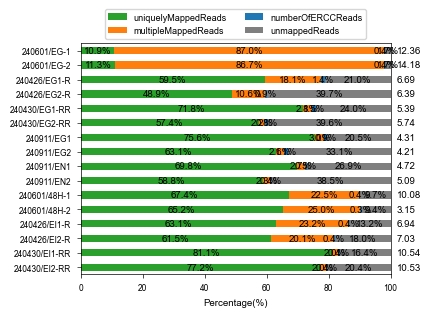

In [69]:
df_plot=df_align_plot.div(df_align_plot.sum(axis=1), axis=0)*100

ax = df_plot.plot(stacked=True, kind='barh',figsize=(4,3),color=["tab:green","tab:orange","tab:blue","tab:grey"])

for bar in ax.patches:
    height = bar.get_height()
    width = bar.get_width()
    x = bar.get_x()
    y = bar.get_y()
    label_text = str(round(width,1))+'%'
    label_x = x + width / 2
    label_y = y + height / 2
    ax.text(label_x, label_y, label_text, ha='center',fontsize=7,    
            va='center')
    
for i in range(0,len(bases)):
    ax.text(102,i,str(round(bases[i],2)),fontsize=7,ha='left',va='center' )
# Display chart
ax.set_xlabel('Percentage(%)')
ax.set_ylabel('')
ax.set_ylim(len(bases)-0.5,-0.5)
ax.legend(bbox_to_anchor =(0.5, 1),loc='lower center',ncol=2)
ax.set_xlim(0,100)
plt.savefig("fig.72_lib.pdf",bbox_inches = 'tight', pad_inches = 0.1)

In [ ]:
df_cor_clippond=pd.read_csv("/wanglab1/gangx/data2/HLF/CLIP_comp/IGF2BP1.csv")

In [816]:
df_cor_clippond_log1p=df_cor_clippond.apply(np.log1p)

meta NOT subset; don't know how to subset; dropped


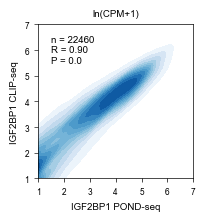

In [820]:
fig, ax = plt.subplots(1, 1, figsize=(2,2))
#df_cor_clippond_log1p.set_index("Unnamed: 0",inplace=True)
cmap = plt.get_cmap('Blues')
new_cmap = truncate_colormap(cmap, 0.0, 0.88)
sns.kdeplot(data=df_cor_clippond_log1p.loc[list(set(df_gene['GENEID'])&set(df_cor_clippond_log1p.index))],
        x='POND', y='CLIP',
        cmap=new_cmap, fill=True,
        clip=(1, 8), cut=10,
        thresh=0.1, levels=12,
        ax=ax,
    )
ax.set_xlim(1,7)
ax.set_ylim(1,7)
ax.set_xlabel("IGF2BP1 POND-seq")
ax.set_ylabel("IGF2BP1 CLIP-seq")
#ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_title("ln(CPM+1)")
pr=pearsonr(df_cor_clippond_log1p.loc[list(set(df_gene['GENEID'])&set(df_cor_clippond_log1p[df_cor_clippond_log1p[['CLIP','POND']].min(1)>0].index))]['CLIP'],df_cor_clippond_log1p.loc[list(set(df_gene['GENEID'])&set(df_cor_clippond_log1p[df_cor_clippond_log1p[['CLIP','POND']].min(1)>0].index))]['POND'])
ax.text(x=1.5,y=5.5,s="n = %d\nR = %.2f\nP = %.1f"%(df_cor_clippond_log1p.loc[list(set(df_gene['GENEID'])&set(df_cor_clippond_log1p[df_cor_clippond_log1p[['CLIP','POND']].min(1)>0].index))].shape[0],pr[0],pr[1]),fontsize=7)
plt.savefig("fig.74_cpm.pdf",bbox_inches = 'tight', pad_inches = 0.1)